# Discussion 4 – Regression Trees and Ensemble Methods

## Welcome 👋

In this notebook, you will:

- Build intuition for regression trees using **Airbnb hotel price prediction**  
- Learn how bagging, random forests reduce variance  
- See how boosting improves predictive performance  

## Learning Goals

By the end of this discussion, you will be able to:

1. Implement regression trees using sklearn  
3. Use bagging, random forests, and boosting to improve predictive performance  
4. Understand the intuition behind hyperparameter tuning

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay

random_seed = 42

## Load Dataset

In [3]:
# STEP 1: DATA CLEANING
data = pd.read_csv('airbnb.csv')
display(data.head(3))

# some columns used ',' for '.'
# need to revert before casting to float
cols_to_convert = ['price', 'bathrooms', 'host response rate', 'host acceptance rate']
data[cols_to_convert] = data[cols_to_convert].replace(',', '.', regex=True).astype(float)

# remove columns without interpretable meaning
df = data.drop(columns = ['reply time', 'host since', 'consumer'])

# remove rows with missing price (y value)
df = df.loc[~data['price'].isna()]

# realized nan in host Certification means no 
print(df['host Certification'].unique())
df['host Certification'] = df['host Certification'].fillna(0)

# double check for missing values
print(df.isnull().sum())

# FINAL DATASET
df = df[['city', 'area', 'guest favourite', 'host Certification', 
         'room_type', 'host total listings count', 'total reviewers number',
         'accommodates', 'bathrooms', 'bedrooms', 'beds', 'listing number',
         'host response rate', 'host acceptance rate', 'price']]

/var/folders/7s/7pz0sdt94z3dpk3yrw82q8jm0000gn/T/ipykernel_1168/1728354008.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('airbnb.csv')


,id,name,host_id,host_name,city,price,reply time,guest favourite,host since,host Certification,...,total reviewers number,accommodates,bathrooms,bedrooms,beds,listing number,host response rate,host acceptance rate,sales,area
0,1,Beautiful Victorian Home,1368256,Robert,Toronto,250,0.0,0,4563,1.0,...,47,6,"1,5",2,3,1,"0,9","0,42",102,North America
1,2,"World Class @ CN Tower, convention centre, The...",113345,Adela,Toronto,152,0.0,0,5120,1.0,...,42,4,1,1,2,5,"0,9","0,42",166,North America
2,3,Furnished room in lovely Annex house June -Oct31,1466410,Susan,Toronto,120,0.0,0,4534,1.0,...,0,1,1,1,2,2,1,"0,65",181,North America


[ 1. nan]
id                           0
name                         0
host_id                      0
host_name                    0
city                         0
price                        0
guest favourite              0
host Certification           0
room_type                    0
host total listings count    0
total reviewers number       0
accommodates                 0
bathrooms                    0
bedrooms                     0
beds                         0
listing number               0
host response rate           0
host acceptance rate         0
sales                        0
area                         0
dtype: int64


## Part 1: Data Exploration

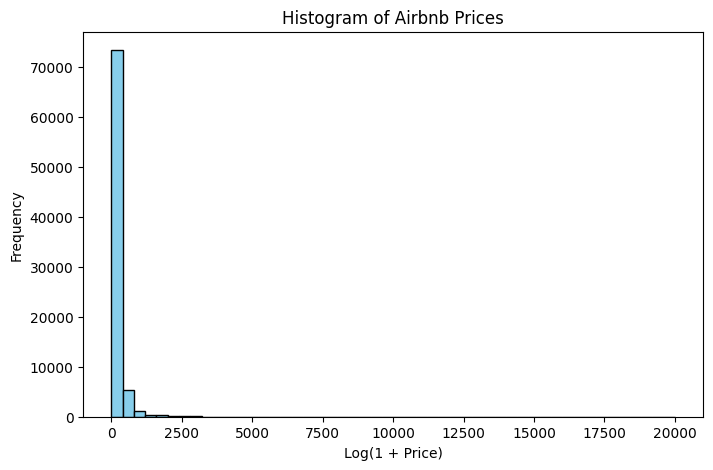

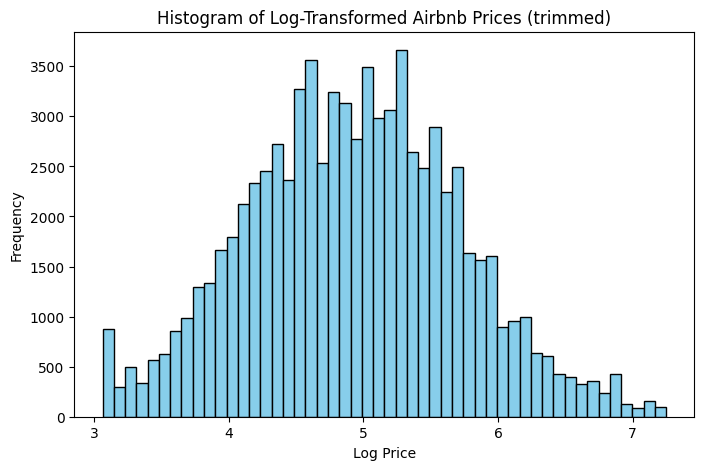

In [147]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Log(1 + Price)')
plt.ylabel('Frequency')
plt.title('Histogram of Airbnb Prices')
plt.show()

# TODO: Clip top and bottom 1% of price, and perform log transformation
# Plot the distribution of log price

In [148]:
# turn numeric-like categorical variables to appropriate data types
df_clean['guest favourite'] = df_clean['guest favourite'].astype(bool)
df_clean['host Certification'] = df_clean['host Certification'].astype(bool)
df_clean['room_type'] = df_clean['room_type'].astype(str)

numeric_cols = ['host total listings count', 'total reviewers number', 'accommodates', 
                'bathrooms', 'bedrooms', 'beds', 'listing number', 'host response rate','host acceptance rate']

categorical_cols = ['city', 'area', 'guest favourite', 'host Certification', 'room_type']

# TODO: Print summary statistics of all variables
# Note: we want different information for numeric vs. categorical vars

Numeric Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
host total listings count,79181.0,23.882901,74.907372,1.000000,1.000000,3.000000,12.000000,837.000000
total reviewers number,79181.0,36.480103,76.208486,0.000000,1.000000,9.000000,37.000000,2575.000000
accommodates,79181.0,3.353645,2.311675,1.000000,2.000000,2.000000,4.000000,16.000000
bathrooms,79181.0,1.064586,0.746480,0.000000,1.000000,1.000000,1.000000,12.000000
bedrooms,79181.0,1.217502,1.060938,0.000000,1.000000,1.000000,2.000000,21.000000
beds,79181.0,1.870285,1.656299,0.000000,1.000000,1.000000,2.000000,60.000000
listing number,79181.0,46.777080,267.884378,1.000000,1.000000,3.000000,14.000000,4818.000000
host response rate,79181.0,0.823278,0.355410,0.000000,0.920000,1.000000,1.000000,1.000000
host acceptance rate,79181.0,0.752017,0.347340,0.000000,0.620000,0.950000,1.000000,1.000000
logprice,79181.0,4.928859,0.788684,3.064725,4.382027,4.934474,5.472271,7.248504



Categorical Summary Statistics:


,count,unique,top,freq
city,79181,11,sydney,13752
area,79181,3,North America,34716
guest favourite,79181,2,False,57550
host Certification,79181,2,True,76029
room_type,79181,4,3,53211


Correlation of numeric predictors with LogPrice:

accommodates                 0.513622
bedrooms                     0.404839
beds                         0.340346
bathrooms                    0.241099
host acceptance rate         0.042258
listing number               0.018937
total reviewers number      -0.013910
host response rate          -0.048705
host total listings count   -0.164986
dtype: float64


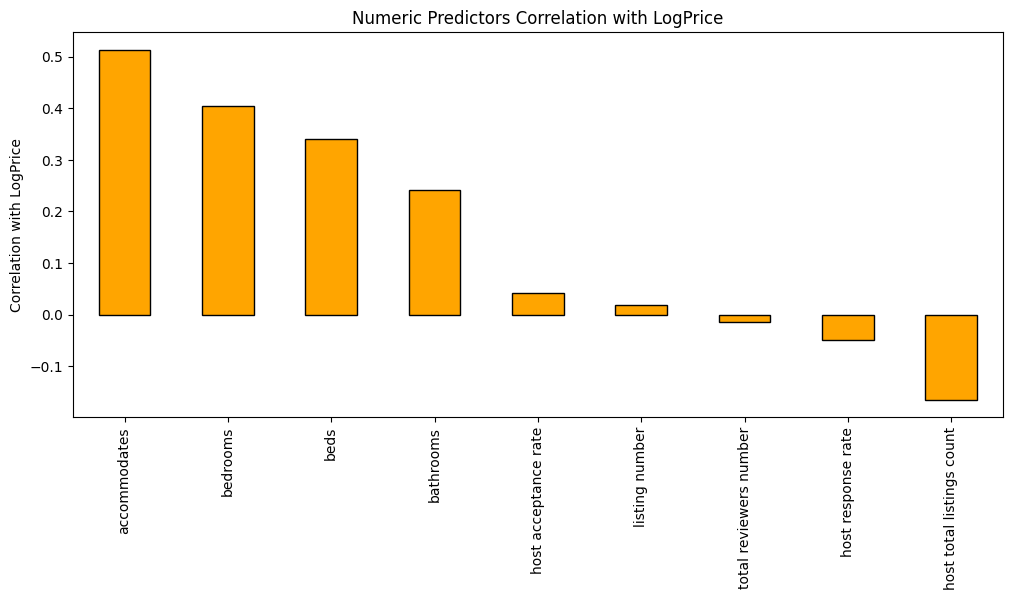

In [149]:
# TODO: Compute the correlation between each predictor and the outcome.

In [150]:
X = df_clean[numeric_cols + categorical_cols]
y = df_clean['logprice']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=random_seed
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=random_seed
)

# TODO: Report the mean and standard deviation of y in each split.

Logprice Statistics by Split:
Training set: n=47508, mean=4.929, std=0.787
Validation set: n=15836, mean=4.932, std=0.790
Test set: n=15837, mean=4.926, std=0.791


## Part 3: Linear Regression Benchmark

In [151]:
# TODO: Fit an OLS benchmark
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ]
)

ols_pipeline = Pipeline(# fill in)

ols_pipeline.fit(X_train, y_train)

y_train_pred = ols_pipeline.predict(X_train)
y_val_pred = ols_pipeline.predict(X_val)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

print(f"OLS Train RMSE: {train_rmse:.4f}")
print(f"OLS Validation RMSE: {val_rmse:.4f}")

OLS Train RMSE: 0.5238
OLS Validation RMSE: 0.5212


## Part 4: Regression Trees

In [153]:
# TODO: Fit a baseline regression tree
tree_pipeline = Pipeline(# fill in)

baseline_tree = tree_pipeline
baseline_tree.fit(X_train, y_train)

y_train_pred = baseline_tree.predict(X_train)
y_val_pred = baseline_tree.predict(X_val)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

print(f"Training RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")

Training RMSE: 0.1265
Validation RMSE: 0.5843


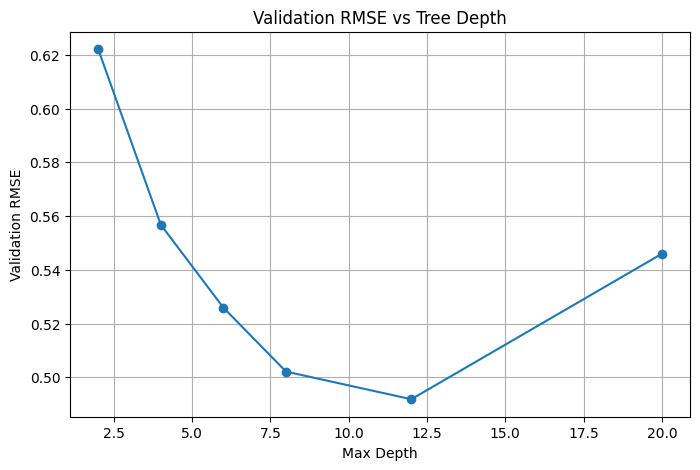

Best depth (d*): 12


In [154]:
# TODO: Depth tuning of decision tree
depths = [2, 4, 6, 8, 12, 20]
val_rmse_depth = []

for d in depths:
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        # fill in
    ])
    pipe.fit(X_train, y_train)
    y_val_pred = pipe.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_rmse_depth.append(rmse)

# TODO: Plot validation RMSE vs depth

# TODO: Select depth minimizing validation RMSE

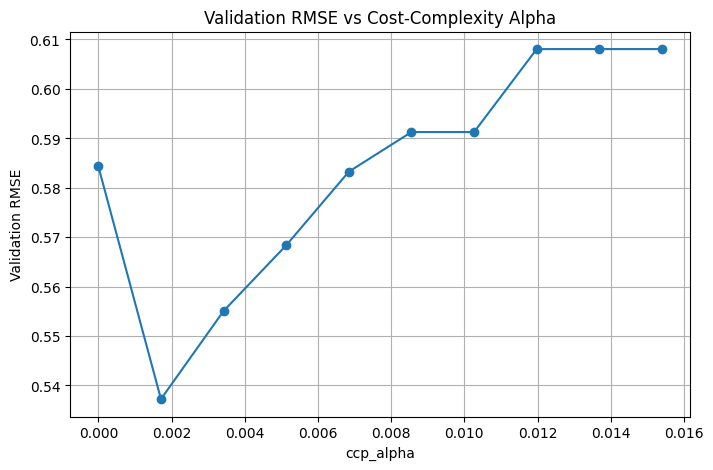

Best ccp_alpha (alpha*): 0.001711
Validation RMSE at alpha*: 0.537


In [156]:
# Get the ccp_alphas from pruning path
full_tree = DecisionTreeRegressor(random_state=random_seed)
X_train_proc = preprocessor.fit_transform(X_train)
full_tree.fit(X_train_proc, y_train)

path = full_tree.cost_complexity_pruning_path(X_train_proc, y_train)
ccp_alphas = path.ccp_alphas

# Focus on small alphas to avoid underfitting
ccp_alphas = ccp_alphas[ccp_alphas >= 0]
ccp_grid = np.linspace(0, ccp_alphas.max()/10, 10)

# TODO: Prune trees with different alpha values 

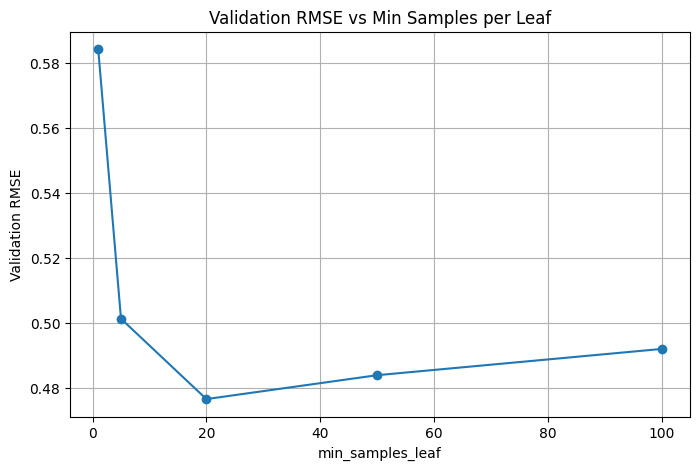

Best min_samples_leaf: 20
Validation RMSE at best leaf size: 0.476


In [157]:
min_leaf_sizes = [1, 5, 20, 50, 100]
val_rmse_leaf = []

# TODO: Tune minimum leaf size

In [159]:
# Depth-tuned tree
depth_tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(max_depth=best_depth, random_state=random_seed))
])
depth_tree.fit(X_train, y_train)

y_train_pred = depth_tree.predict(X_train)
y_val_pred = depth_tree.predict(X_val)

# Get underlying tree object
regressor_depth = depth_tree.named_steps['regressor']

print("Depth-Tuned Tree Stats:")
print(f"Number of leaves: {regressor_depth.get_n_leaves()}")
print(f"Maximum depth: {regressor_depth.get_depth()}")
print(f"Training RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"Validation RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred)):.4f}")

# CCP-pruned tree
pruned_tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(ccp_alpha=best_ccp_alpha, random_state=random_seed))
])
pruned_tree.fit(X_train, y_train)

y_train_pred = pruned_tree.predict(X_train)
y_val_pred = pruned_tree.predict(X_val)

regressor_pruned = pruned_tree.named_steps['regressor']

print("\nPruned Tree Stats:")
print(f"Number of leaves: {regressor_pruned.get_n_leaves()}")
print(f"Maximum depth: {regressor_pruned.get_depth()}")
print(f"Training RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"Validation RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred)):.4f}")

Depth-Tuned Tree Stats:
Number of leaves: 2270
Maximum depth: 12
Training RMSE: 0.4366
Validation RMSE: 0.4918

Pruned Tree Stats:
Number of leaves: 24
Maximum depth: 8
Training RMSE: 0.5363
Validation RMSE: 0.5372


## Part 5: Bagging and Random Forest

In [4]:
# TODO: Fit a bagging model with 200 trees
# what does n_estimators represent? how does it affect model performance?

NameError: name 'preprocessor' is not defined

In [165]:
max_features_options = ['sqrt', 0.5, 1.0]
val_rmse_rf = []

# TODO: Tune max_features in random forest with n_estimators = 200

Random Forest (max_features=sqrt): Validation RMSE = 0.4407
Random Forest (max_features=0.5): Validation RMSE = 0.4409
Random Forest (max_features=1.0): Validation RMSE = 0.4462
Best max_features: sqrt
Validation RMSE: 0.4407


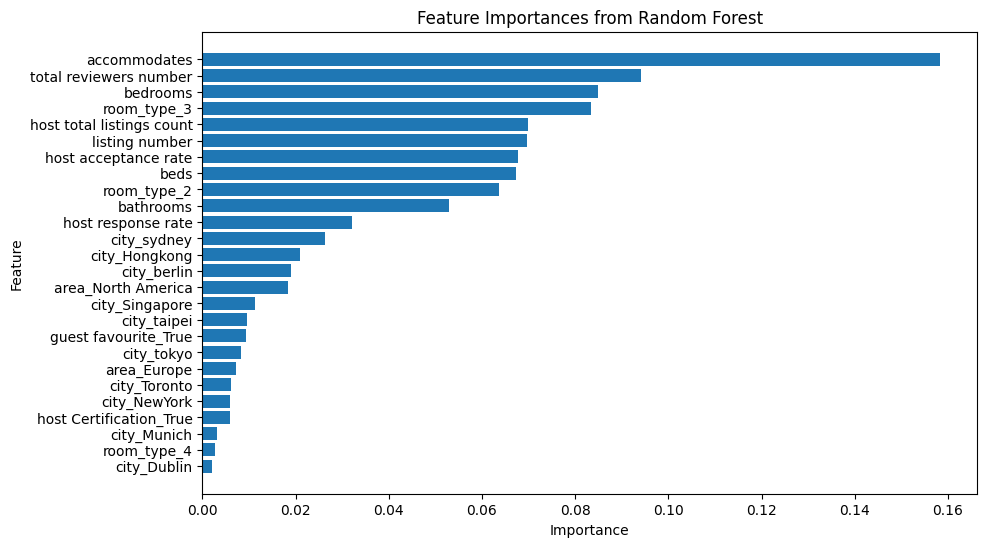

Top 10 features by importance:
                      feature  importance
19               accommodates    0.158414
18     total reviewers number    0.094106
21                   bedrooms    0.084801
15                room_type_3    0.083364
17  host total listings count    0.069788
23             listing number    0.069585
25       host acceptance rate    0.067717
22                       beds    0.067289
14                room_type_2    0.063682
20                  bathrooms    0.052922


In [166]:
# Fit random forest with the best max feature
best_rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_features=best_mf,
        random_state=random_seed
    ))
])
best_rf_pipeline.fit(X_train, y_train)

feature_names_cat = best_rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
feature_names = np.concatenate([feature_names_cat, numeric_cols])

importances = best_rf_pipeline.named_steps['regressor'].feature_importances_
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances from Random Forest')
plt.show()

print("Top 10 features by importance:")
print(feat_imp_df.head(10))

## Part 6: Boosting

Gradient Boosting (n_estimators=50): Validation RMSE = 0.5343
Gradient Boosting (n_estimators=100): Validation RMSE = 0.5044
Gradient Boosting (n_estimators=200): Validation RMSE = 0.4877
Gradient Boosting (n_estimators=400): Validation RMSE = 0.4751


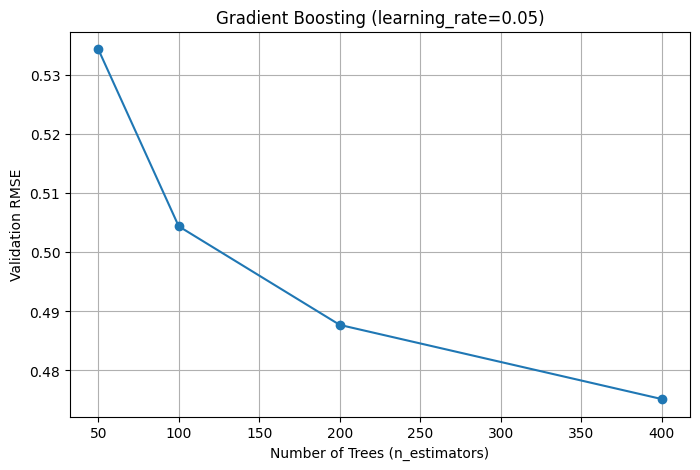

Best n_estimators: 400
Validation RMSE at best n_estimators: 0.4751


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [170]:
learning_rate = 0.05
n_estimators_options = [50, 100, 200, 400]
val_rmse_gb = []

for n_est in n_estimators_options:
    gb_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', GradientBoostingRegressor(
            n_estimators=n_est,
            learning_rate=learning_rate,
            random_state=random_seed
        ))
    ])
    gb_pipeline.fit(X_train, y_train)
    y_val_pred = gb_pipeline.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_rmse_gb.append(rmse)
    print(f"Gradient Boosting (n_estimators={n_est}): Validation RMSE = {rmse:.4f}")

# Plot validation RMSE vs number of trees
plt.figure(figsize=(8,5))
plt.plot(n_estimators_options, val_rmse_gb, marker='o')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Validation RMSE')
plt.title(f'Gradient Boosting (learning_rate={learning_rate})')
plt.grid(True)
plt.show()

# Select best number of trees
best_n_estimators = n_estimators_options[np.argmin(val_rmse_gb)]
print(f"Best n_estimators: {best_n_estimators}")
print(f"Validation RMSE at best n_estimators: {min(val_rmse_gb):.4f}")

# Fit final Gradient Boosting model
best_gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=best_n_estimators,
        learning_rate=learning_rate,
        random_state=42
    ))
])
best_gb_pipeline.fit(X_train, y_train)

## Part 7: Partial Dependence and Economic Nonlinearities

Partial Dependence Plots: Best Ensemble Model


/Users/ericazhou/miniconda3/lib/python3.13/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/Users/ericazhou/miniconda3/lib/python3.13/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 4 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


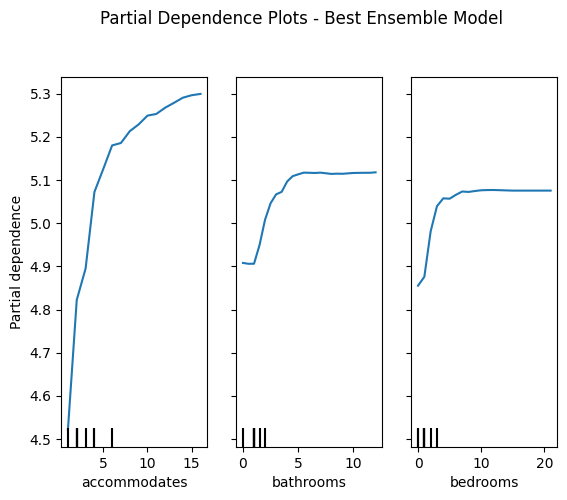

Partial Dependence Plots: OLS Benchmark


/Users/ericazhou/miniconda3/lib/python3.13/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/Users/ericazhou/miniconda3/lib/python3.13/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 4 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


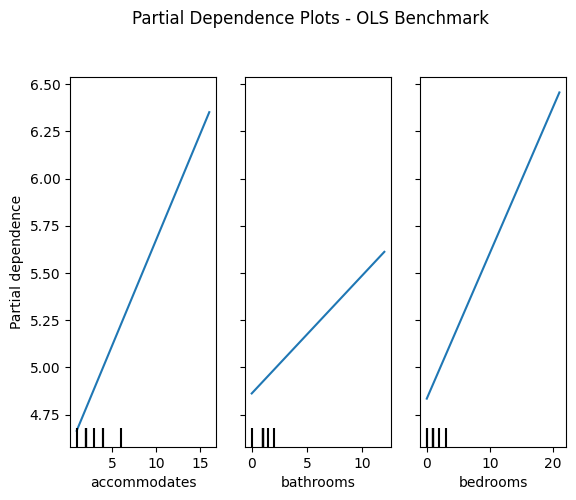

In [172]:
# Features for PDP
pdp_features = ['accommodates', 'bathrooms', 'bedrooms']
best_model_pipeline = best_rf_pipeline

# TODO: PDP for best ensemble model and OLS

## Part 8: Final Model Evaluation

In [174]:
models = {
    'OLS Benchmark': ols_pipeline,
    'Depth-Tuned Tree': depth_tree,
    'Pruned Tree (alpha*)': pruned_tree,
    'Bagging (200 trees)': bagging_pipeline,
    'Random Forest': best_rf_pipeline,
    'Gradient Boosting': best_gb_pipeline
}

# Evaluate each model on the test set
test_results = []

for name, pipeline in models.items():
    y_test_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_results.append({'Model': name, 'Test RMSE': rmse})

results_df = pd.DataFrame(test_results)

# Compute percent improvement over OLS
ols_rmse = results_df.loc[results_df['Model'] == 'OLS Benchmark', 'Test RMSE'].values[0]
results_df['% Improvement vs OLS'] = 100 * (ols_rmse - results_df['Test RMSE']) / ols_rmse
results_df['Test RMSE'] = results_df['Test RMSE'].round(4)
results_df['% Improvement vs OLS'] = results_df['% Improvement vs OLS'].round(2)

results_df

,Model,Test RMSE,% Improvement vs OLS
0,OLS Benchmark,0.5254,0.00
1,Depth-Tuned Tree,0.4967,5.46
2,Pruned Tree (alpha*),0.5412,-3.01
3,Bagging (200 trees),0.4488,14.59
4,Random Forest,0.4434,15.60
5,Gradient Boosting,0.4823,8.21
